<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/practica20_267370.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez



## Mario Amador - 267370.

### Instrucciones de la tarea: Análisis Exploratorio de Datos (EDA)

Objetivo

Realizar un Análisis Exploratorio de Datos (EDA) aplicando técnicas estadísticas y de visualización para comprender la estructura, distribución y relaciones dentro de un conjunto de datos.

Utilza el archivo AirQuality que se proprociona

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Introducción del dataset

**Nombre del dataset:** AirQuality

**Fuente:** Dataset proporcionado por el Dr. Vicente.

## Descripción general

Este dataset contiene mediciones ambientales registradas a lo largo del tiempo, incluyendo variables meteorológicas y concentraciones de dióxido de nitrógeno (NO₂) en diferentes ubicaciones.

Los datos tienen características de **serie temporal (time series)**, ya que cada registro está asociado a una fecha y hora específica.


## Dimensiones del dataset

- **Número de observaciones:** 8784
- **Número de variables:** 8


## Descripción de variables

- **DateTime:** Fecha y hora de la medición (tipo objeto)
- **Temperature:** Temperatura ambiental (°C)
- **Humidity:** Humedad relativa (%)
- **Wind_Speed:** Velocidad del viento
- **Wind_Direction:** Dirección del viento (grados)
- **NO2_Location_A:** Concentración de NO₂ en ubicación A
- **NO2_Location_B:** Concentración de NO₂ en ubicación B
- **NO2_Location_C:** Concentración de NO₂ en ubicación C

## Observaciones importantes

- La variable **DateTime** es de tipo objeto, por lo que puede convertirse a formato datetime para análisis temporales.
- Existen valores faltantes en las variables de NO₂ (especialmente en Location B).
- Las variables son principalmente numéricas, lo que facilita el análisis estadístico y visual.

In [30]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/Unidad02/Airdata.csv')

df.head()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
0,1/1/2020 0:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37
1,1/1/2020 1:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53
2,1/1/2020 2:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80
3,1/1/2020 3:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80
4,1/1/2020 4:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43


In [31]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DateTime        8784 non-null   object 
 1   Temperature     8784 non-null   float64
 2   Humidity        8784 non-null   int64  
 3   Wind_Speed      8784 non-null   float64
 4   Wind_Direction  8784 non-null   float64
 5   NO2_Location_A  8664 non-null   float64
 6   NO2_Location_B  8204 non-null   float64
 7   NO2_Location_C  8652 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 549.1+ KB


# 2.  Exploración inicial de datos


In [32]:
# Valores faltantes
df.isnull().sum()

,0
DateTime,0
Temperature,0
Humidity,0
Wind_Speed,0
Wind_Direction,0
NO2_Location_A,120
NO2_Location_B,580
NO2_Location_C,132


In [33]:
# Porcentaje de los valores nulos
(df.isnull().sum() / len(df)) * 100

,0
DateTime,0.000000
Temperature,0.000000
Humidity,0.000000
Wind_Speed,0.000000
Wind_Direction,0.000000
NO2_Location_A,1.366120
NO2_Location_B,6.602914
NO2_Location_C,1.502732


**Interpretación:**

Se identifican valores faltantes en las variables:

- NO2_Location_A
- NO2_Location_B
- NO2_Location_C

La variable con mayor cantidad de datos faltantes es **NO2_Location_B**, lo cual podría afectar análisis posteriores.

El resto de las variables no presentan valores nulos, lo que indica buena calidad en las mediciones meteorológicas.

Estos valores faltantes deberán ser considerados en etapas posteriores (eliminación o imputación).

In [34]:
# Tipos de datos
df.dtypes


,0
DateTime,object
Temperature,float64
Humidity,int64
Wind_Speed,float64
Wind_Direction,float64
NO2_Location_A,float64
NO2_Location_B,float64
NO2_Location_C,float64


In [35]:
print("Después de convertir a formato datetime")
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.dtypes

Después de convertir a formato datetime


,0
DateTime,datetime64[ns]
Temperature,float64
Humidity,int64
Wind_Speed,float64
Wind_Direction,float64
NO2_Location_A,float64
NO2_Location_B,float64
NO2_Location_C,float64


In [36]:
df.head()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
0,2020-01-01 00:00:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37
1,2020-01-01 01:00:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53
2,2020-01-01 02:00:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80
3,2020-01-01 03:00:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80
4,2020-01-01 04:00:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43


In [37]:
# Estadísticas descriptivas
df.describe()

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8664.000000,8204.000000,8652.000000
mean,2020-07-01 23:30:00,13.110913,66.679417,11.279210,197.595605,22.047992,29.000569,45.347931
min,2020-01-01 00:00:00,-2.789471,20.000000,0.000000,1.218872,-0.460000,0.430000,0.150000
25%,2020-04-01 11:45:00,7.360529,56.000000,5.506941,116.565050,10.600000,13.900000,24.030000
50%,2020-07-01 23:30:00,12.680529,68.000000,8.891343,206.138925,17.550000,22.750000,40.550000
75%,2020-10-01 11:15:00,18.553030,78.000000,14.720416,272.503370,29.300000,38.607500,62.122500
max,2020-12-31 23:00:00,33.870530,98.000000,65.446770,360.000000,116.600000,151.850000,168.280000
std,NaN,7.363943,14.871943,8.443103,91.961627,15.597173,20.630746,26.735531


**Interpretación:**

Las estadísticas descriptivas permiten observar:

- La temperatura tiene una media de aproximadamente 13°C, con valores entre -2.8°C y 33.8°C.
- La humedad promedio es de 66% (Lo cual podría llegar a ser húmedo)
- La velocidad del viento presenta alta variabilidad (8.44/11.27 = 75%), con valores extremos elevados.
- Las concentraciones de NO₂ muestran dispersión significativa (65.44 - 0), lo que sugiere cambios en la calidad del aire dependiendo del tiempo y la ubicación.

En general, el dataset presenta características típicas de datos ambientales reales.

In [38]:
# Ver duplicados
df.duplicated().sum()

np.int64(0)

**Interpretación:**

No se identifican registros duplicados (o son mínimos), lo que indica que cada observación corresponde a una medición única en el tiempo.

**Conclusión de la exploración inicial:**

El dataset presenta buena calidad en general, con datos completos en variables meteorológicas y algunos valores faltantes en las mediciones de NO₂.

Se detectaron valores atípicos que podrían representar condiciones reales del entorno.

El dataset es adecuado para continuar con análisis univariado, bivariado y multivariado.

# 3. Análisis univariado


Para el análisis univariado se eligió *Temperature* ya que es continua, no tiene valores faltantes y representa las condiciones ambientales base del df.

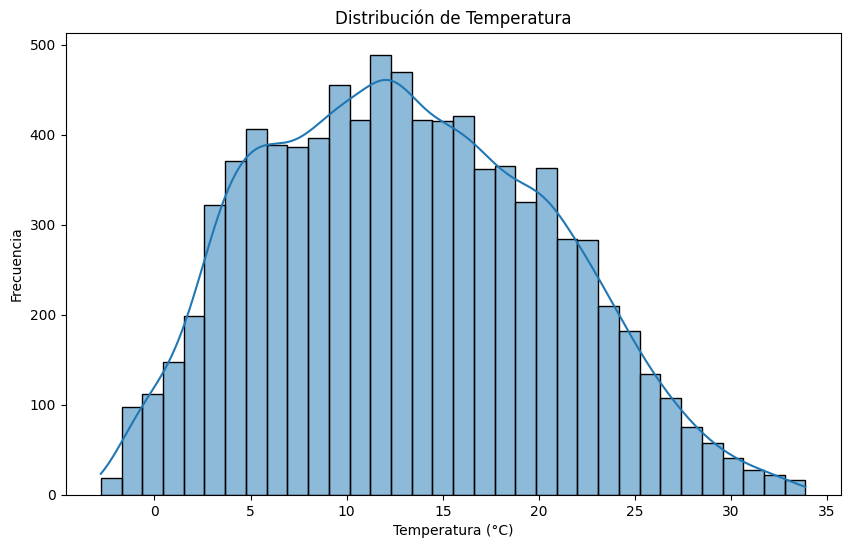

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Temperature'], kde=True)
plt.title('Distribución de Temperatura')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')
plt.show()

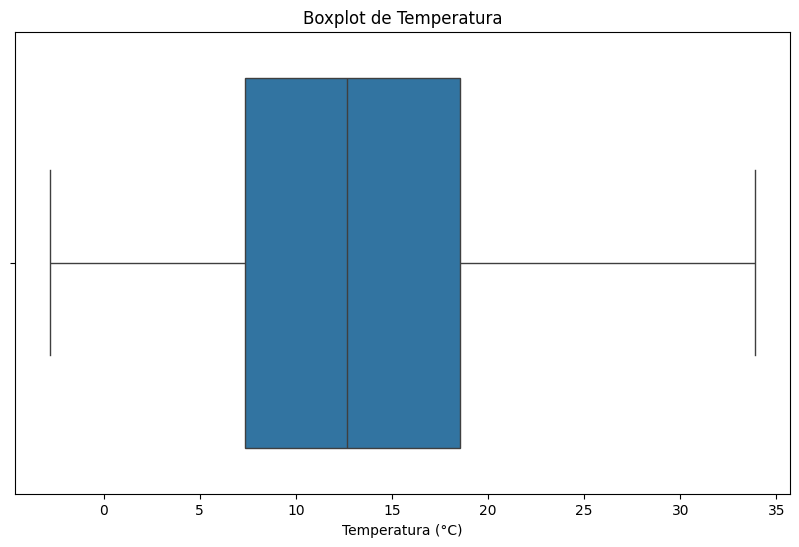

In [40]:
# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Temperature'])
plt.title('Boxplot de Temperatura')
plt.xlabel('Temperatura (°C)')
plt.show()

**Interpretación:**

La distribución de la temperatura presenta una forma aproximadamente normal, con mayor concentración de valores entre 7°C y 18°C.

El histograma muestra una distribución relativamente simétrica, lo que indica que no existe un sesgo pronunciado.

El boxplot confirma que la mayoría de los valores se encuentran dentro de un rango esperado, donde no se muestran valores atípicos.

Esto sugiere que la temperatura es una variable estable y consistente dentro del dataset.

Por curiosidad también se realizaron gráficas con la velocidad del viento para confirmar la alta variabilidad

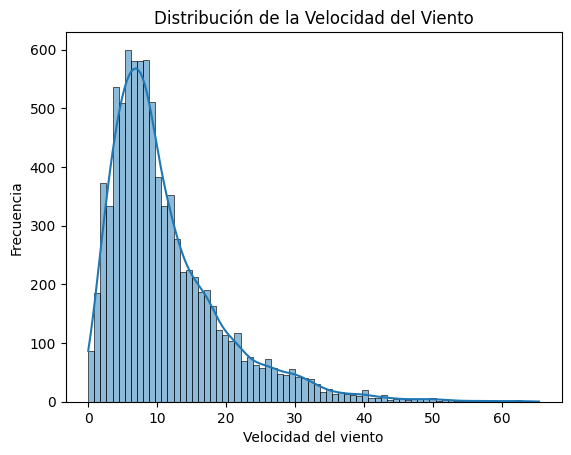

In [41]:
plt.figure()
sns.histplot(df['Wind_Speed'], kde=True)
plt.title('Distribución de la Velocidad del Viento')
plt.xlabel('Velocidad del viento')
plt.ylabel('Frecuencia')
plt.show()

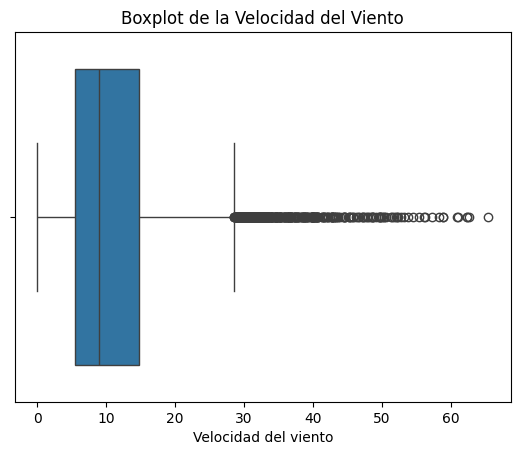

In [42]:
plt.figure()
sns.boxplot(x=df['Wind_Speed'])
plt.title('Boxplot de la Velocidad del Viento')
plt.xlabel('Velocidad del viento')
plt.show()

**Interpretación:**

La distribución de la velocidad del viento presenta una asimetría positiva (sesgo a la derecha), donde la mayoría de los valores se concentran en niveles bajos a moderados.

Sin embargo, se observan valores extremos elevados, lo cual se refleja en la cola larga hacia la derecha en el histograma.

El boxplot evidencia la presencia de múltiples valores atípicos.

Esto confirma la alta variabilidad observada previamente, indicando que existen cambios importantes en la intensidad del viento a lo largo del tiempo.

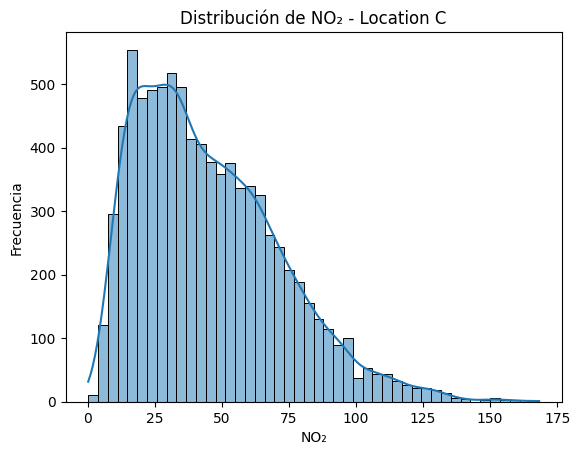

In [43]:
#NO2 En la locación C
plt.figure()
sns.histplot(df['NO2_Location_C'].dropna(), kde=True)
plt.title('Distribución de NO₂ - Location C')
plt.xlabel('NO₂')
plt.ylabel('Frecuencia')
plt.show()

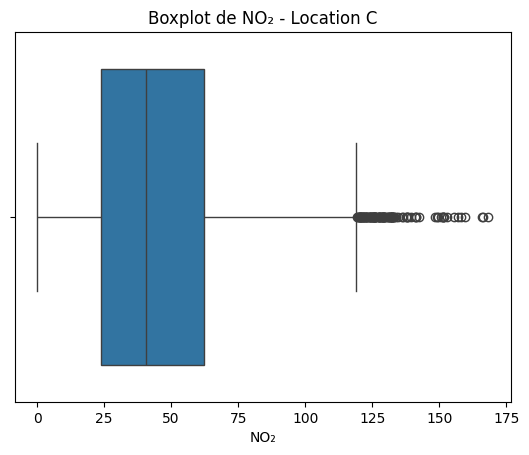

In [44]:
plt.figure()
sns.boxplot(x=df['NO2_Location_C'])
plt.title('Boxplot de NO₂ - Location C')
plt.xlabel('NO₂')
plt.show()

**Interpretación:**

La distribución de NO₂ en la ubicación C presenta una alta dispersión y una asimetría positiva.

Se observa que la mayoría de los valores se concentran en niveles bajos a moderados, pero existen valores extremos elevados que generan una cola larga hacia la derecha.

El boxplot muestra múltiples valores atípicos, lo que indica la presencia de picos de contaminación.

Esto sugiere que la calidad del aire varía significativamente dependiendo del tiempo, con episodios ocasionales de alta contaminación.

**Conclusión del análisis univariado:**

Las variables analizadas muestran distintos comportamientos:

- La temperatura presenta una distribución estable y aproximadamente normal.
- La velocidad del viento muestra alta variabilidad y presencia de valores extremos.
- Las concentraciones de NO₂ presentan alta dispersión y episodios de valores elevados.

Esto indica que el dataset contiene tanto variables estables como variables altamente variables, lo cual es característico de datos ambientales.

# Análisis bivariado

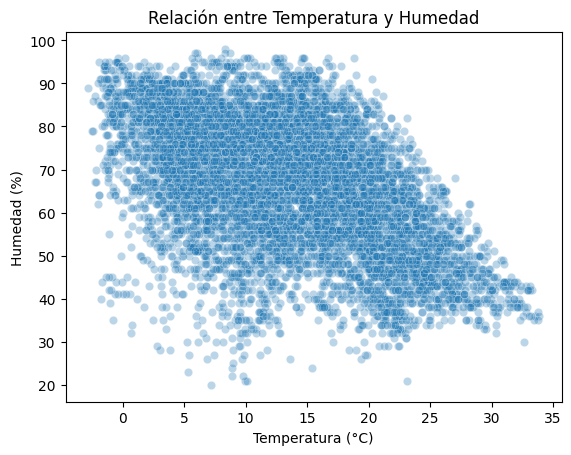

In [45]:
# Análisis bivariado
# Temperatura vs humedad, para saber si existe alguna relación entre ambos (Scatter plot)

plt.figure()
sns.scatterplot(x=df['Temperature'], y=df['Humidity'], alpha=0.3)
plt.title('Relación entre Temperatura y Humedad')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Humedad (%)')
plt.show()

**Interpretación:**

Se observa una tendencia inversa entre la temperatura y la humedad.
A medida que la temperatura aumenta, la humedad tiende a disminuir.

Sin embargo, la alta dispersión de los datos indica que la relación no es fuerte y que intervienen otros factores.

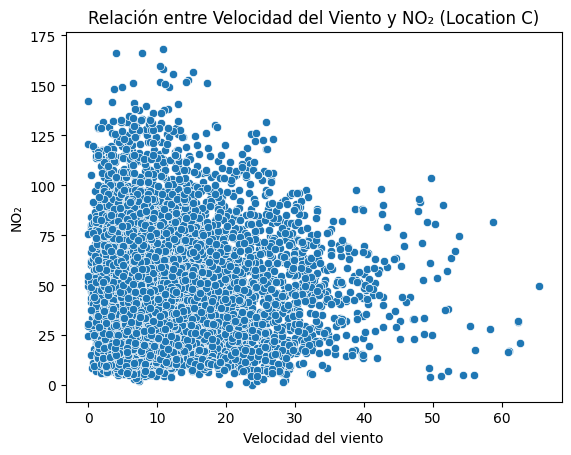

In [46]:
# Relación entre la velocidad del viento y NO2

plt.figure()
sns.scatterplot(x=df['Wind_Speed'], y=df['NO2_Location_C'])
plt.title('Relación entre Velocidad del Viento y NO₂ (Location C)')
plt.xlabel('Velocidad del viento')
plt.ylabel('NO₂')
plt.show()

**Interpretación:**

Se observa una tendencia general donde, a mayores velocidades del viento, las concentraciones de NO₂ tienden a disminuir.

Esto puede explicarse porque el viento ayuda a dispersar los contaminantes en la atmósfera.

Sin embargo, existe una alta dispersión en los datos, lo que indica que esta relación no es fuerte y podría llegar a depender de otros factores.

**Conclusión del análisis bivariado:**

Se identificaron relaciones importantes entre variables:

- Existe una posible relación inversa entre temperatura y humedad.
- La velocidad del viento parece influir en la dispersión de contaminantes.

Estas relaciones permiten comprender mejor el comportamiento del sistema ambiental analizado.

# Análisis multivariado

In [47]:
# Seleccionar solo variables numéricas
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Matriz de correlación
corr = df_numeric.corr()

corr

,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
Temperature,1.000000,-0.513544,-0.143839,0.016461,-0.147364,-0.170846,-0.027245
Humidity,-0.513544,1.000000,-0.033073,0.094668,0.048492,0.024416,-0.066503
Wind_Speed,-0.143839,-0.033073,1.000000,0.210817,0.012427,0.088063,0.024166
Wind_Direction,0.016461,0.094668,0.210817,1.000000,-0.005739,0.045909,-0.021615
NO2_Location_A,-0.147364,0.048492,0.012427,-0.005739,1.000000,0.819928,0.616725
NO2_Location_B,-0.170846,0.024416,0.088063,0.045909,0.819928,1.000000,0.673614
NO2_Location_C,-0.027245,-0.066503,0.024166,-0.021615,0.616725,0.673614,1.000000


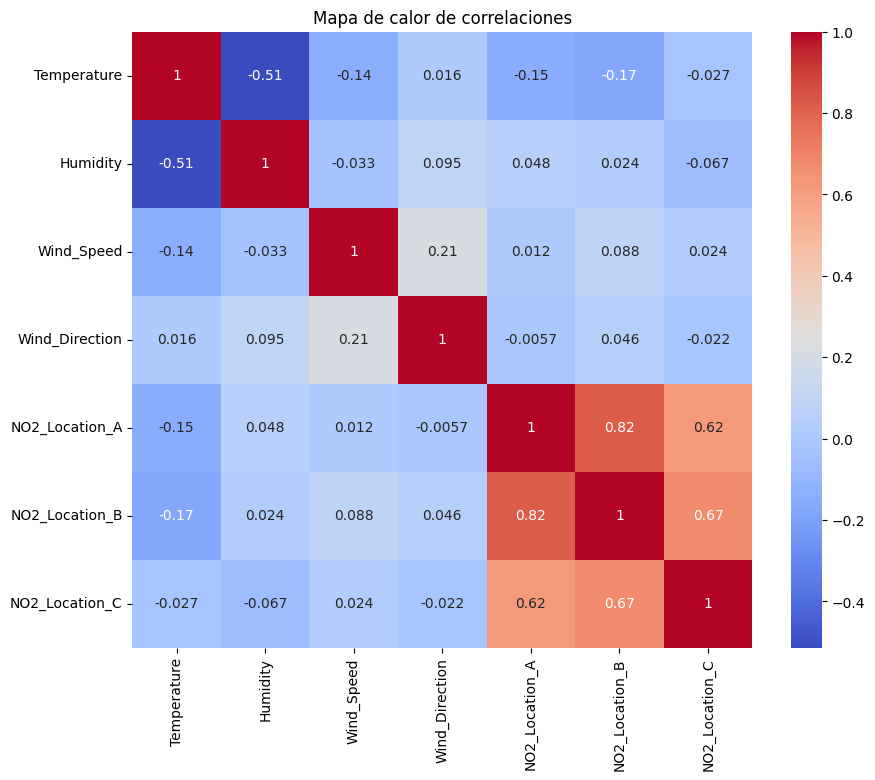

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlaciones')
plt.show()

**Interpretación:**

El mapa de calor muestra la correlación entre todas las variables numéricas del dataset.

Se observan los siguientes puntos relevantes:

- Existe una correlación negativa entre la temperatura y la humedad, lo cual confirma lo observado en el análisis bivariado.
- Las variables de NO₂ (Location A, B y C) presentan correlaciones positivas entre sí, lo que indica que los niveles de contaminación tienden a comportarse de forma similar en distintas ubicaciones.
- La velocidad del viento muestra correlaciones débiles con otras variables, lo que sugiere que su influencia no es lineal o está mediada por otros factores.
- No se observan correlaciones extremadamente altas (cercanas a 1 o -1), lo que indica que no hay relaciones lineales perfectas entre las variables.

**En general, las correlaciones encontradas son moderadas o débiles**

# 6. Identificación de patrones

## ¿Qué patrones importantes encontraste?

Se identificaron distintos comportamientos en las variables del dataset:

- La temperatura presenta una distribución estable y aproximadamente normal.
- La velocidad del viento muestra alta variabilidad, con presencia de valores extremos.
- Las concentraciones de NO₂ presentan una alta dispersión, con cambios significativos a lo largo del tiempo.

Esto indica que el dataset combina variables relativamente estables con otras altamente variables.


## ¿Existen relaciones entre variables?

Sí, se identificó lo siguiente:

- Existe una relación inversa entre la temperatura y la humedad, donde a mayor temperatura, menor humedad relativa.
- Se observa una relación positiva entre las concentraciones de NO₂ en distintas ubicaciones, lo que sugiere que los niveles de contaminación tienden a comportarse de manera similar en diferentes puntos.
- La velocidad del viento muestra una relación débil con las concentraciones de NO₂, lo que indica que su efecto en la dispersión de contaminantes no es completamente lineal.

## ¿Se observan clusters naturales?

No se identifican clusters claramente definidos en las visualizaciones.

Los datos presentan una distribución continua, especialmente en los scatter plots, pero no hay clusters visibles.


## ¿Existen outliers?

Sí, se detectaron valores atípicos en las concentraciones de NO₂

Estos valores extremos pueden representar eventos reales, como condiciones climáticas inusuales o picos de contaminación, por lo que no necesariamente deben ser eliminados.


## ¿Qué variables parecen ser más relevantes?

Las variables más relevantes dentro del análisis son:

- **NO2_Location_A, NO2_Location_B y NO2_Location_C**, ya que representan directamente la calidad del aire, lo cual considero el punto fuerte de este dataset.
- **Temperature y Humidity**, debido a su relación y su influencia en condiciones ambientales.
- **Wind_Speed**, ya que puede influir en la dispersión de contaminantes.

Estas variables permiten explicar gran parte del comportamiento del sistema analizado.